__Optimal Brain Damage__ (LeCun, Denker & Solla, NeurIPS 1989) — одна из первых работ о прунинге нейросетей. Основная идея: использовать вторые производные функции потерь, чтобы определить, какие веса можно безболезненно удалить.

## Ключевая идея

Авторы рассматривают изменение лосса вокруг точки оптимума и раскладывают его в ряд Тейлора. 

Напоминим, что для функции одной переменной $f: \mathbb{R} \to \mathbb{R}$ разложение в окрестности точки $x_0$ выглядит как

$$
f(x_0 + \delta x) = f(x_0) + f'(x_0) \, \delta x + \tfrac{1}{2} f''(x_0) \, \delta x^2 + \tfrac{1}{6} f'''(x_0) \, \delta x^3 + \ldots
$$<br>

Для функции многих переменных $f: \mathbb{R}^n \to \mathbb{R}$ всё аналогично, только производные превращаются в векторы и матрицы. В точке $\theta_0 \in \mathbb{R}^n$:

$$
f(\theta_0 + \delta\theta) = f(\theta_0) + \nabla f(\theta_0)^\top \delta\theta + \tfrac{1}{2} \, \delta\theta^\top H(\theta_0) \, \delta\theta + O(\|\delta\theta\|^3)
$$

где:

- $\nabla f(\theta_0) \in \mathbb{R}^n$ — градиент, вектор первых частных производных,
- $H(\theta_0) \in \mathbb{R}^{n \times n}$ — гессиан, матрица вторых частных производных,
- $\delta\theta \in \mathbb{R}^n$ — приращение аргумента
<br>

Если расписать матрично-векторные операции покомпонентно:<br>
$
\nabla f^\top \delta\theta = \sum_i \frac{\partial f}{\partial \theta_i} \, \delta\theta_i = \sum_i g_i \, \delta\theta_i
$

$\delta\theta^\top H \, \delta\theta = \sum_{i,j} h_{ij} \, \delta\theta_i \, \delta\theta_j$

Обозначая $\delta\mathcal{L} = \mathcal{L}(\theta_0 + \delta\theta) - \mathcal{L}(\theta_0)$, получаем центральную формулу:

$$
\delta \mathcal{L} = \sum_i g_i \, \delta\theta_i + \tfrac{1}{2} \bigg(\sum_i h_{ii} \, \delta\theta_i^2 + \sum_{i \neq j} h_{ij} \, \delta\theta_i \, \delta\theta_j \bigg) + O(\|\delta\theta\|^3)
$$

Дальше делаются три упрощающих допущения:

1) Сеть обучена до (локального) минимума, поэтому градиенты $g_i \approx 0$ и линейный член отбрасывается. Мы находимся в точке устойчивого равновесия$$
\delta \mathcal{L} = \tfrac{1}{2} \bigg(\sum_i h_{ii} \, \delta\theta_i^2 + \sum_{i \neq j} h_{ij} \, \delta\theta_i \, \delta\theta_j \bigg) + O(\|\delta\theta\|^3)
$$
2) Гессиан считается диагональным — недиагональные члены $h_{ij}$ игнорируются. Это главное упрощение работы и оно же даёт название «approximation»$$
\delta \mathcal{L} \approx \tfrac{1}{2} \bigg(\sum_i h_{ii} \, \delta\theta_i^2\bigg) + O(\|\delta\theta\|^3)
$$<br>
  интерпретация: в окрестности точки $\theta_{opt}$ многомерная функция $f(\theta)$ приближается параболоидом* (задаваемым матрицей H), а в нашем случае, считаем что он всегда декоррелированный: расположенный вдоль осей
3) Возмущения малы и кубическими членами можно пренебречь.$$
\delta \mathcal{L} \approx \tfrac{1}{2} \bigg(\sum_i h_{ii} \, \delta\theta_i^2\bigg)
$$

*Параболоид не обязательно эллипический. Его форма определяется собсвтенными значениями Гессиана: при значениях одного знака - эллиптический, при разных знаках гиперболический.

В работе (2016) [Eigenvalues of the Hessian in Deep Learning: Singularity and Beyond](https://arxiv.org/pdf/1611.07476) исследовали, как выглядят Гессианы в реальных сетях. Чаще всего они эллиптические, с большим кол-вом вырожденных измерений

В итоге для удаления одного веса ($\delta\theta_i = -\theta_i$) вклад в изменение лосса оценивается как:

$$
s_i = \tfrac{1}{2} h_{ii} \, \theta_i^2
$$

Эту величину авторы называют __saliency__ веса. Она интерпретируется так: важен не сам по себе маленький вес, а маленькое произведение «вес² × кривизна». Вес может быть большим по модулю, но если соответствующая диагональ гессиана близка к нулю, его удаление почти не повлияет на лосс.

То есть мы смотрим, насколько "плоско" ведет себя Loss в точке локального минимума для каждого параметра. Если плоско, значит параметр особо не влияет на точность и его можно занулить

<img src = "img/saliency_loss.png" width=600>

NOTE это не значит, что параметр ведет себя также "вне" области локального оптимума. Это именно свойство уже обучениной модели

## Алгоритм

1. Обучить сеть до сходимости.
2. Вычислить $h_{ii}$ для всех весов (авторы используют эффективную процедуру обратного распространения вторых производных, аналогичную backprop для первых).
3. Посчитать saliency $s_i = h_{ii} \theta_i^2 / 2$.
4. Удалить веса с наименьшим $s_i$.
5. Дообучить сеть.
6. При необходимости повторить.

## Эксперименты и результат

Метод тестировался на задаче распознавания рукописных цифр (предшественник MNIST, ~9 тысяч обучающих примеров) с свёрточной сетью со ~~2,6 тыс. весов. OBD позволил удалить значительную часть параметров (порядка половины и больше) с минимальной или даже улучшенной обобщающей способностью — благодаря регуляризационному эффекту прунинга.

Авторы также показали, что saliency на основе гессиана коррелирует с magnitude, но не совпадает с ним: чисто magnitude-based прунинг удалял заметно больше «важных» весов при той же степени разреженности.

## Историческое значение

- Первая работа, поставившая прунинг в строгие рамки оптимизации второго порядка.
- Ввела понятие saliency, которое до сих пор используется в литературе.
- Прямое продолжение — Optimal Brain Surgeon (Hassibi & Stork, 1993), где отказались от диагонального приближения и добавили формулу пересчёта оставшихся весов для компенсации удалённых.
- Современные методы прунинга больших моделей (WoodFisher, M-FAC, SparseGPT) — это, по сути, попытки масштабировать ту же идею второго порядка на сети с миллиардами параметров, где честно посчитать или хранить даже диагональ гессиана становится нетривиально.

Практически одновременно с OBD вышла работа Майкла Мозера и Пола Смоленски __Skeletonization__, тоже про прунинг. Они формулировали идею ещё прямее: задача — найти минимальный «скелет» сети, способный реализовать ту же функцию. Smolensky в своих более теоретических работах того периода (PTC framework) явно настаивал, что у распределённых представлений нет привилегированного базиса, и приписывание смысла отдельным весам или нейронам — категориальная ошибка.

Перепараметризованная сеть имеет много эквивалентных решений — целое многообразие в пространстве параметров, дающее одинаковый лосс.
Прунинг не ищет «настоящие» параметры. Он находит одно из многих разреженных решений, лежащее рядом с плотным.
Какой именно вес «важен» — артефакт пути обучения. При другой инициализации и другом порядке батчей важными оказались бы другие веса, реализующие ту же функцию.

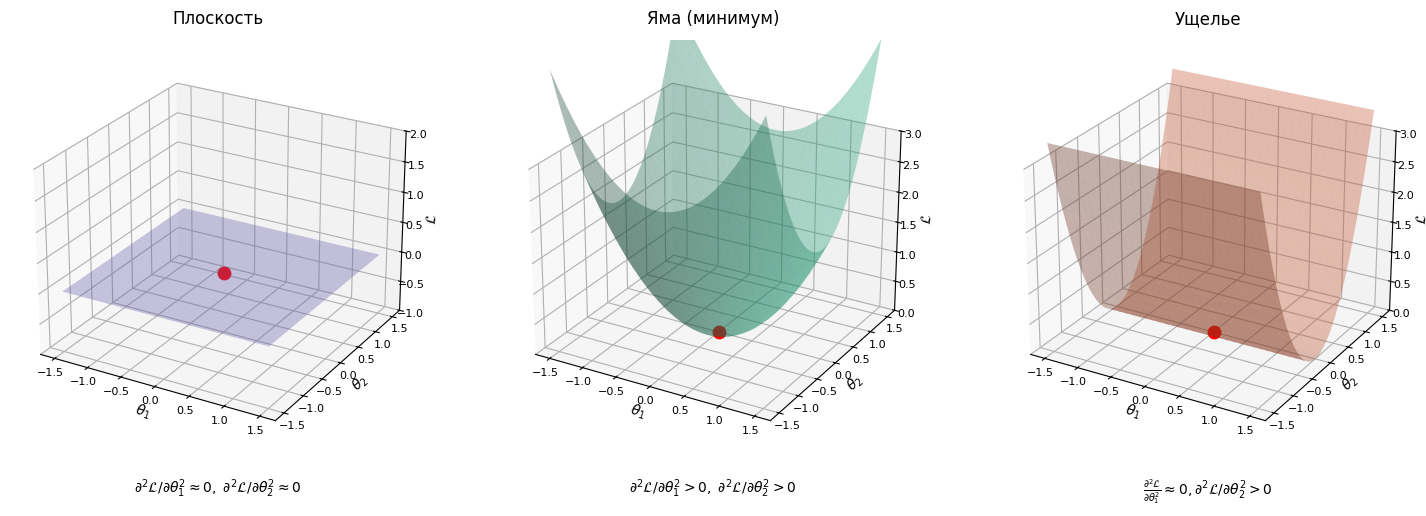

In [4]:
"""
Визуализация трёх типов поверхности функции потерь в окрестности
критической точки и соответствующих собственных значений гессиана.

1. Плоскость:        H ≈ 0           (оба λ ≈ 0)         — вырожденный случай
2. Эллиптическая яма: H положительно определён (оба λ > 0) — настоящий минимум
3. Ущелье:           один λ = 0, второй > 0              — вырожденный минимум
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Сетка одна и та же для всех трёх случаев
GRID = 60
LIM = 1.5
x = np.linspace(-LIM, LIM, GRID)
y = np.linspace(-LIM, LIM, GRID)
X, Y = np.meshgrid(x, y)


def make_axes(ax, title, subtitle):
    """Общие настройки для 3D-осей."""
    ax.set_xlabel(r'$\theta_1$', labelpad=-8)
    ax.set_ylabel(r'$\theta_2$', labelpad=-8)
    ax.set_zlabel(r'$\mathcal{L}$', labelpad=-8)
    ax.set_title(title, pad=12, fontsize=12)
    # Подзаголовок с производными — пишем под осями
    ax.text2D(0.5, -0.05, subtitle, transform=ax.transAxes,
              ha='center', va='top', fontsize=10)
    ax.tick_params(axis='both', which='major', pad=-3, labelsize=8)
    ax.view_init(elev=25, azim=-60)


fig = plt.figure(figsize=(15, 5))

# =========================================================================
# 1. ПЛОСКОСТЬ — функция почти не меняется во всех направлениях
# =========================================================================
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
Z1 = np.zeros_like(X) + 0.01 * (X + Y) * 0  # ровно плоскость
ax1.plot_surface(X, Y, Z1, alpha=0.35, color='#7F77DD',
                 edgecolor='none', rstride=2, cstride=2)
# Красная точка посередине
ax1.scatter([0], [0], [0], color='red', s=80, zorder=10, depthshade=False)
ax1.set_zlim(-1, 2)
make_axes(ax1, 'Плоскость',
          r'$\partial^2\mathcal{L}/\partial\theta_1^2 \approx 0,\ '
          r'\partial^2\mathcal{L}/\partial\theta_2^2 \approx 0$')

# =========================================================================
# 2. ЭЛЛИПТИЧЕСКАЯ ЯМА — настоящий минимум
# =========================================================================
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
Z2 = 0.8 * X**2 + 1.2 * Y**2  # обе кривизны положительные
ax2.plot_surface(X, Y, Z2, alpha=0.35, color='#1D9E75',
                 edgecolor='none', rstride=2, cstride=2)
ax2.scatter([0], [0], [0], color='red', s=80, zorder=10, depthshade=False)
ax2.set_zlim(0, 3)
make_axes(ax2, 'Яма (минимум)',
          r'$\partial^2\mathcal{L}/\partial\theta_1^2 > 0,\ '
          r'\partial^2\mathcal{L}/\partial\theta_2^2 > 0$')

# =========================================================================
# 3. УЩЕЛЬЕ — вырожденный минимум, одно направление плоское
# =========================================================================
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
Z3 = 1.5 * Y**2  # кривизна только по θ_2, по θ_1 — ноль
ax3.plot_surface(X, Y, Z3, alpha=0.35, color='#D85A30',
                 edgecolor='none', rstride=2, cstride=2)
ax3.scatter([0], [0], [0], color='red', s=80, zorder=10, depthshade=False)
ax3.set_zlim(0, 3)
make_axes(ax3, 'Ущелье',
          r'$\frac{\partial^2\mathcal{L}}{\partial\theta_1^2} \approx 0,'
          r'\partial^2\mathcal{L}/\partial\theta_2^2 > 0$')

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.savefig('loss_landscapes.png', dpi=150, bbox_inches='tight')
plt.show()